# 1. YOLO v3를 이용하여 물체를 검출하는 프로그램을 수행: a 방법으로 진행 

In [23]:
import numpy as np
import cv2 as cv2
import sys
import matplotlib.pyplot as plt

# YOLO 모델 및 클래스 불러오기

def construct_yolo_v3():
    
    f = open('yolo/coco_names.txt', 'r')

    class_names = [line.strip() for line in f.readlines()]
    
    model = cv2.dnn.readNet('yolo/yolov3.weights', 'yolo/yolov3.cfg')
    
    layer_names = model.getLayerNames() 
    
    out_layers = [layer_names[i-1] for i in model.getUnconnectedOutLayers()]
    
    return model, out_layers, class_names

In [24]:
# 객체 검출 함수

def yolo_detect(img, yolo_model, out_layers):

    height, width = img.shape[0], img.shape[1]
    
    test_img = cv2.dnn.blobFromImage(img, 1.0/256, (448,448), (0,0,0), swapRB=True)

    yolo_model.setInput(test_img)
    
    output3 = yolo_model.forward(out_layers)

    box, conf, id = [], [], []
    
    for output in output3:
        
        for vec85 in output:
            scores = vec85[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            
            if confidence > 0.5:   # 신뢰도 50% 이상만 추출
                centery, centerx = int(vec85[0]*width), int(vec85[1]*height)
                w, h = int(vec85[2]*width), int(vec85[3]*height)
                x, y = int(centerx-w/2), int(centery-h/2)

                box.append([x, y, x+w, y+h])
                
                conf.append(float(confidence))
                
                id.append(class_id)

    ind = cv2.dnn.NMSBoxes(box, conf, 0.5, 0.4)  # 중복 박스 제거(NMS)

    objects = [box[i]+[conf[i], id[i]] for i in range(len(box)) if i in ind]
    
    return objects


In [25]:
# 검출 결과 시각화 및 실행

model, out_layers, class_names = construct_yolo_v3()
colors = np.random.uniform(0,255, size=(len(class_names), 3))

### soccer.jpg에 적용

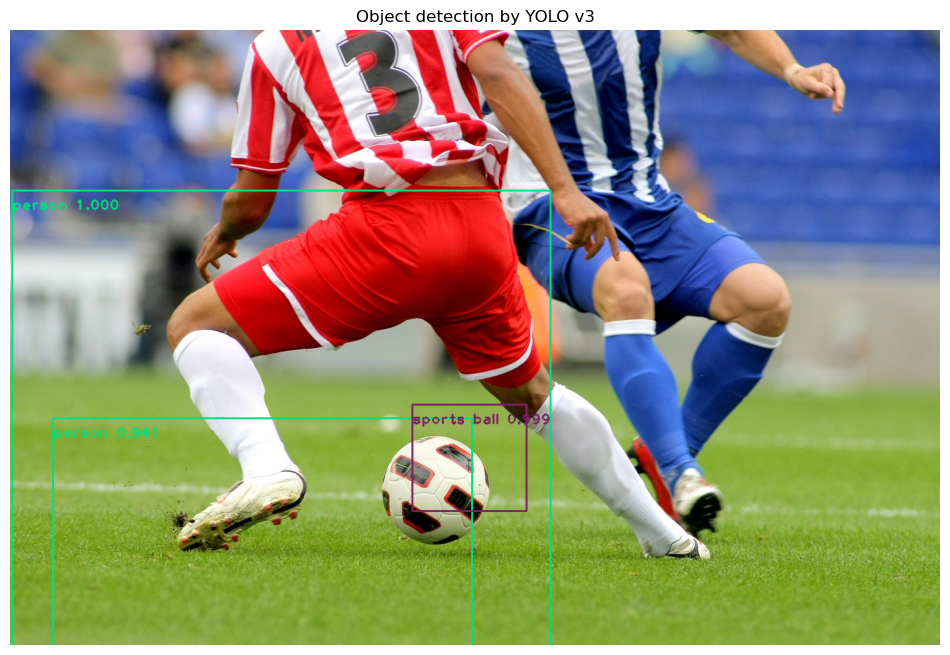

In [26]:
img = cv2.imread('yolo/soccer.jpg')

if img is None:
    sys.exit('파일이 없습니다.')

res = yolo_detect(img, model, out_layers)

for i in range(len(res)):
    x1, y1, x2, y2, confidence, id = res[i]
    text = str(class_names[id]) + ' %.3f' % confidence
    cv2.rectangle(img, (x1, y1), (x2, y2), colors[id], 2)      
    cv2.putText(img, text, (x1, y1+30), cv2.FONT_HERSHEY_PLAIN, 1.5, colors[id], 2) 

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)

plt.axis('off')
plt.title('Object detection by YOLO v3')
plt.show()

### busy_street.jpg에 적용

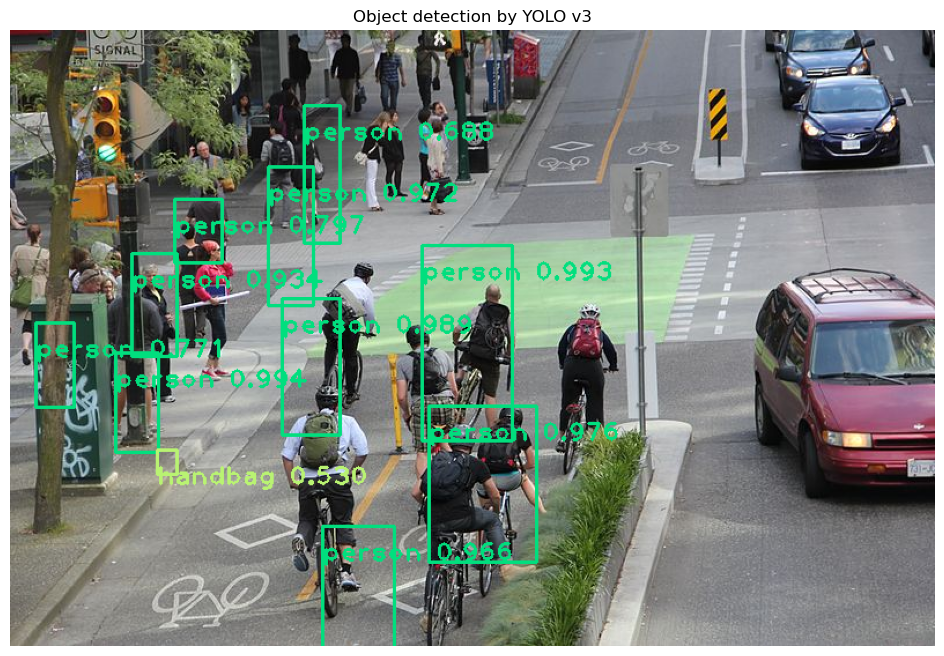

In [27]:
img = cv2.imread('yolo/busy_street.jpg')

if img is None:
    sys.exit('파일이 없습니다.')

res = yolo_detect(img, model, out_layers)

for i in range(len(res)):
    x1, y1, x2, y2, confidence, id = res[i]
    text = str(class_names[id]) + ' %.3f' % confidence
    cv2.rectangle(img, (x1, y1), (x2, y2), colors[id], 2)       # 박스 표시
    cv2.putText(img, text, (x1, y1+30), cv2.FONT_HERSHEY_PLAIN, 1.5, colors[id], 2) # 클래스명+확률 표시

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)

plt.axis('off')
plt.title('Object detection by YOLO v3')
plt.show()

### 교내 도로에서 차량과 사람들이 포함된 영상 취득 후 수행

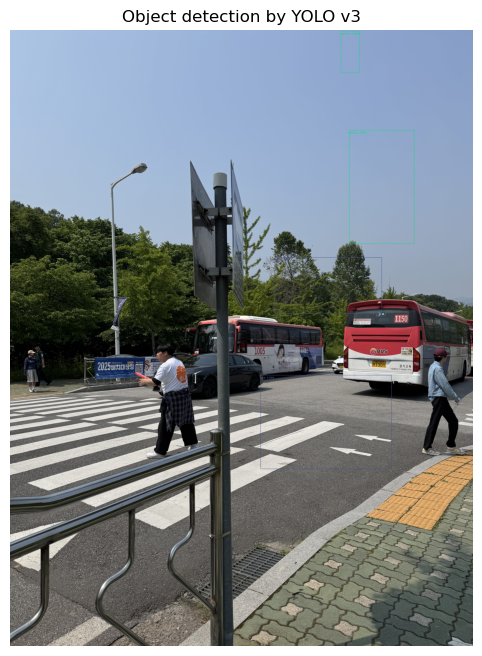

In [33]:
img = cv2.imread('hufs_street.jpeg')

if img is None:
    sys.exit('파일이 없습니다.')

res = yolo_detect(img, model, out_layers)

for i in range(len(res)):
    x1, y1, x2, y2, confidence, id = res[i]
    text = str(class_names[id]) + ' %.3f' % confidence
    cv2.rectangle(img, (x1, y1), (x2, y2), colors[id], 2)       # 박스 표시
    cv2.putText(img, text, (x1, y1+30), cv2.FONT_HERSHEY_PLAIN, 1.5, colors[id], 2) # 클래스명+확률 표시

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)

plt.axis('off')
plt.title('Object detection by YOLO v3')
plt.show()

정확히 나오지 않음 -> 이미지 전처리 적용

In [43]:
import cv2

img = cv2.imread('hufs_street.jpeg')

if img is None:
    print("이미지를 불러올 수 없습니다.")
else:
    height, width = img.shape[:2]
    print(f"입력 이미지 해상도: 너비={width}, 높이={height}")


입력 이미지 해상도: 너비=4284, 높이=5712


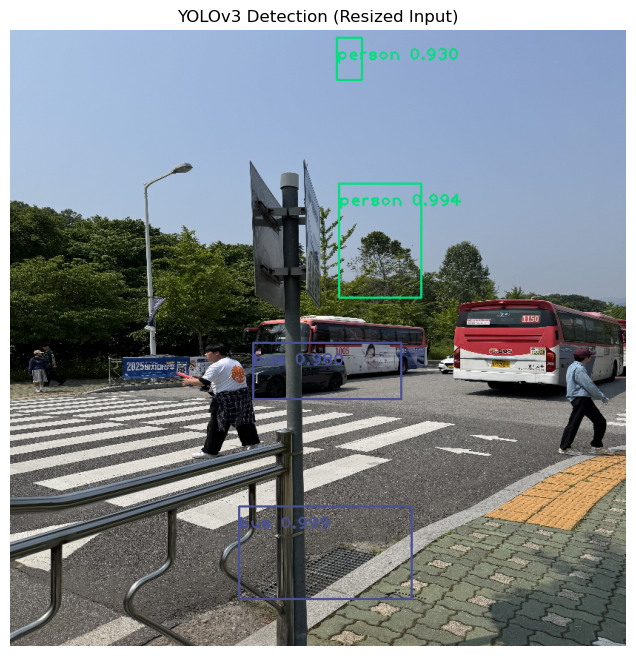

In [41]:
img = cv2.imread('hufs_street.jpeg')

# YOLO에 맞는 해상도로 resize
img = cv2.resize(img, (832, 832))

res = yolo_detect(img, model, out_layers)

for i in range(len(res)):
    x1, y1, x2, y2, confidence, class_id = res[i]
    text = str(class_names[class_id]) + ' %.3f' % confidence
    cv2.rectangle(img, (x1, y1), (x2, y2), colors[class_id], 2)
    cv2.putText(img, text, (x1, y1 + 30), cv2.FONT_HERSHEY_PLAIN, 1.5, colors[class_id], 2)

# 5. RGB로 변환 후 출력
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('YOLOv3 Detection (Resized Input)')
plt.show()


사람과 버스를 대략적으로 감지하지만, 박스에 정확하게 객체에 맞지 않음 -> 박스 좌표 복원

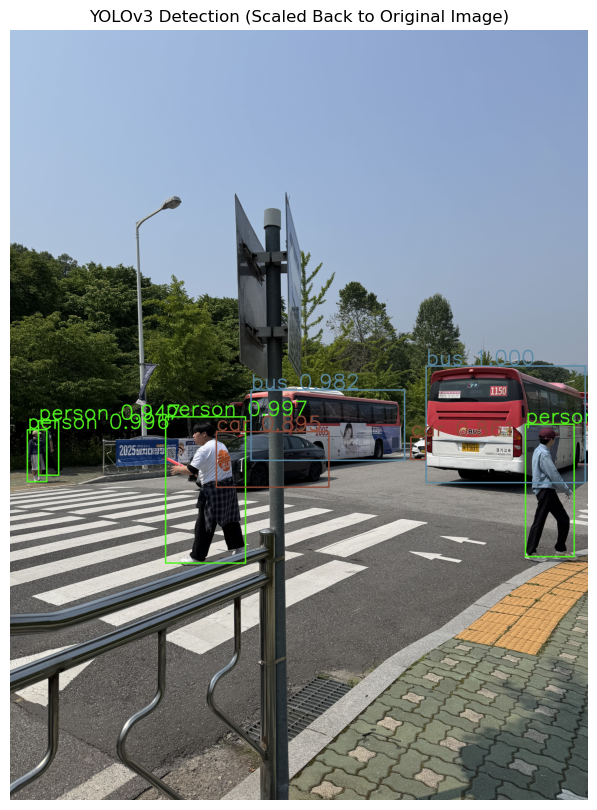

In [49]:
original_img = cv2.imread('hufs_street.jpeg')
if original_img is None:
    sys.exit('파일을 찾을 수 없습니다.')

original_h, original_w = original_img.shape[:2]

resized_img = cv2.resize(original_img, (832, 832))
resized_h, resized_w = resized_img.shape[:2]

model, out_layers, class_names = construct_yolo_v3()
colors = np.random.randint(0, 255, (len(class_names), 3))

res = yolo_detect(resized_img, model, out_layers)

for i in range(len(res)):
    x1, y1, x2, y2, confidence, class_id = res[i]

    scale_x = original_w / resized_w
    scale_y = original_h / resized_h

    x1 = int(x1 * scale_x)
    x2 = int(x2 * scale_x)
    y1 = int(y1 * scale_y)
    y2 = int(y2 * scale_y)

    x1 = max(0, min(x1, original_w - 1))
    x2 = max(0, min(x2, original_w - 1))
    y1 = max(0, min(y1, original_h - 1))
    y2 = max(0, min(y2, original_h - 1))

    label = f"{class_names[class_id]} {confidence:.3f}"
    color = colors[class_id]

    cv2.rectangle(original_img, (x1, y1), (x2, y2), color.tolist(), 10)
    cv2.putText(original_img, label, (x1, max(y1 - 10, 10)), cv2.FONT_HERSHEY_SIMPLEX, 5.0, color.tolist(), 10)

img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('YOLOv3 Detection (Scaled Back to Original Image)')
plt.show()


---

# 2. YOLO v3에서는 물체 검출을 어떻게 수행하는가

출처: 

- https://viso.ai/deep-learning/yolov3-overview/
- https://herbwood.tistory.com/21
- https://pjreddie.com/darknet/yolo/

YOLO v3(You Only Look Once v3)는 단 한 번의 전방향 패스로 전체 이미지를 처리하여 물체를 실시간으로 검출하는 객체 탐지 모델임. 

전체 네트워크는 입력 이미지를 여러 해상도로 처리하며, 각 위치마다 바운딩 박스를 동시에 예측하는 구조로 설계됨.

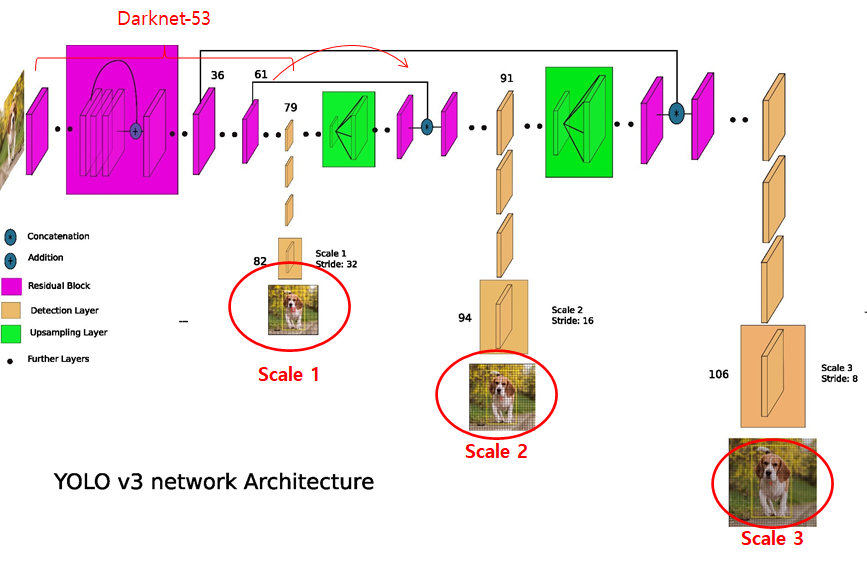

1. 입력 이미지를 resize하여 모델에 입력
2. Darknet-53으로부터 다양한 해상도의 feature map 추출
3. 3개의 스케일에서 각각 객체 탐지를 수행 (큰 물체 ~ 작은 물체까지 대응)
4. 각 grid cell은 anchor box를 기반으로 클래스, 좌표, 신뢰도 예측
5. 세 스케일의 결과를 합쳐서 모든 객체 후보 추출
6. NMS를 적용하여 최종 바운딩 박스 결정

| 그림 요소                             | 설명                                           |
| --------------------------------- | -------------------------------------------- |
| 보라색 블록                            | Darknet-53 (Backbone)                        |
| 녹색 블록                             | Upsampling Layer (FPN 연결)                    |
| 주황색 Detection Layer (82, 94, 106) | YOLO detection 수행 지점                         |
| 빨간 화살표                            | Feature map을 skip connection으로 연결하여 멀티스케일 처리 |


## 1. 이미지 입력 및 그리드 분할

- 입력 이미지의 해상도를 YOLO v3가 요구하는 크기(예: 416×416 또는 608×608)로 변환함.
- 네트워크는 이 이미지를 **S×S 그리드 셀**로 분할함. 예: 13×13, 26×26, 52×52의 크기를 갖는 특징 맵을 생성함.
- 각 그리드 셀은 해당 위치에 물체가 있는지를 판단하는 역할을 수행함.

> 단일 이미지에서 여러 크기의 객체를 탐지하기 위한 위치 기반 프레임 구성 방식.


## 2. 특징 추출: Darknet-53 백본 네트워크

- YOLO v3의 백본은 **Darknet-53**이라는 합성곱 신경망임.
- 53개의 convolution layer와 다수의 residual block으로 구성됨.
- 다양한 깊이의 계층에서 특징 맵을 추출하여, 이미지 내 객체의 저수준~고수준 정보까지 포함함.

> 이미지 전체에서 시각적 패턴(윤곽, 텍스처, 경계 등)을 추출하기 위한 기본 처리기 역할.


## 3. 다중 스케일 특징 맵 기반 탐지

- YOLO v3는 3개의 서로 다른 크기의 특징 맵(13×13, 26×26, 52×52)에서 동시에 탐지를 수행함.
    - **13×13**: 큰 객체 탐지에 적합함.
    - **26×26**: 중간 크기 객체 탐지에 적합함.
    - **52×52**: 작은 객체 탐지에 적합함.
- 이를 통해 다양한 크기의 물체를 한 번에 탐지할 수 있음.

> 큰 객체부터 작은 객체까지 포괄하는 다중 해상도 기반 처리 방식.


## 4. 바운딩 박스 예측 및 클래스 확률 추론

각 그리드 셀은 3개의 앵커 박스(anchor boxes)를 기준으로 물체 유무를 예측함. 각 박스는 다음과 같은 정보를 포함함:

- **박스 중심 좌표 (tx, ty)**
- **박스 너비와 높이 (tw, th)**
- **객체 존재 확률 (objectness score, p₀)**
- **클래스별 확률 분포 (p₁, p₂, ..., p₈₀)**

총 예측 벡터는 `(tx, ty, tw, th, p₀, p₁, ..., p₈₀)`로 구성되며, **박스당 85개 속성**, **셀이 3개의 박스를 예측**하므로 출력 채널은 `255 (85 × 3)`임.

> 하나의 위치에서 여러 개의 후보 박스를 생성하고 각 박스마다 해당 클래스일 확률을 함께 예측.


## 5. 후처리: Confidence 필터링 및 NMS 적용

모든 바운딩 박스 중 유의미한 결과만 남기기 위해 두 단계의 후처리를 수행함.

### 1 - Confidence Thresholding

- 예측된 박스 중 **신뢰도(objectness score × class score)**가 기준 이하(예: 0.5)인 박스를 제거함.

### 2 - Non-Maximum Suppression (NMS)

- 하나의 객체에 대해 여러 박스가 중복될 수 있음.
- NMS는 **가장 높은 신뢰도**를 가진 박스를 남기고, **IOU(Intersection over Union)**가 일정 기준 이상인 다른 박스들을 제거함.

> 최종적으로 가장 유효한 하나의 박스만 남기기 위한 중복 제거 절차.


## 6. 최종 출력 결과 생성

- 남은 박스들의 좌표는 원본 이미지 크기에 맞게 다시 **rescale**함.
- 각 박스는 다음 정보를 포함함:
    - 클래스 이름 (예: person, car)
    - 신뢰도 (예: 0.982)
    - 바운딩 박스 좌표 (x1, y1, x2, y2)

> 이미지 위에 시각적으로 직관적인 결과를 오버레이로 표시함.

---

따라서 위의 YOLOv3 네트워크 아키텍처 그림은 아래의 설명으로 정리 가능:

- 좌측부터 우측으로 흐르며, 특징 추출(보라색 블록), 업샘플링(녹색 블록), detection(오렌지색 블록) 단계가 이어짐.
- **Scale 1 (Stride 32)**, **Scale 2 (Stride 16)**, **Scale 3 (Stride 8)** 세 가지 해상도에서 예측이 이루어짐.
- 이 구조는 **FPN(Feature Pyramid Network)** 구조와 유사하며, 작은 객체까지 놓치지 않고 감지하는 데 효과적임.